# 06 — CNN Backbone Exploration

Test ConvNeXt-V2 and EfficientNet backbones on synthetic fundus images.
Verify:
- Output shapes are correct
- Forward pass works end-to-end
- Gradient flow is healthy
- Memory usage is acceptable

In [1]:
import sys
sys.path.insert(0, "..")

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from src.models.backbones import ConvNeXtBackbone, EfficientNetBackbone, VisualFieldEncoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cpu


## 1. ConvNeXt-Small Backbone

In [2]:
# Test with random "fundus" images
B = 4
dummy_images = torch.randn(B, 3, 224, 224).to(device)

convnext = ConvNeXtBackbone(pretrained=False).to(device)  # pretrained=False for quick test
print(f"ConvNeXt params: {sum(p.numel() for p in convnext.parameters()):,}")

with torch.no_grad():
    feats = convnext(dummy_images)
print(f"Output shape: {feats.shape}")  # Expected: (4, 768)
print(f"Feature stats: mean={feats.mean():.4f}, std={feats.std():.4f}")

ConvNeXt params: 49,453,152
Output shape: torch.Size([4, 768])
Feature stats: mean=-0.0004, std=0.1100


## 2. EfficientNet-B3 Backbone

In [3]:
efficientnet = EfficientNetBackbone(pretrained=False).to(device)
print(f"EfficientNet params: {sum(p.numel() for p in efficientnet.parameters()):,}")

with torch.no_grad():
    feats_eff = efficientnet(dummy_images)
print(f"Output shape: {feats_eff.shape}")  # Expected: (4, 1536)

EfficientNet params: 10,696,232
Output shape: torch.Size([4, 1536])


## 3. Visual Field Encoder

In [4]:
T = 6     # visits
N_VF = 54 # 24-2 VF points
dummy_vf = torch.randn(B, T, N_VF).to(device)

vf_enc = VisualFieldEncoder(n_points=N_VF, hidden_dim=256).to(device)
print(f"VF encoder params: {sum(p.numel() for p in vf_enc.parameters()):,}")

with torch.no_grad():
    vf_feats = vf_enc(dummy_vf)
print(f"VF encoded shape: {vf_feats.shape}")  # Expected: (4, 6, 256)

VF encoder params: 80,896
VF encoded shape: torch.Size([4, 6, 256])


## 4. Gradient Flow Check

In [5]:
# Gradient flow — check that all layers receive gradients
def check_gradient_flow(model, x):
    """Check if gradients flow through all named parameters."""
    model.train()
    out = model(x)
    loss = out.mean()
    loss.backward()
    
    dead_layers = []
    for name, param in model.named_parameters():
        if param.grad is None:
            dead_layers.append(name)
        elif param.grad.abs().max() == 0:
            dead_layers.append(f"{name} (zero grad)")
    
    if dead_layers:
        print(f"WARNING: {len(dead_layers)} layers with no/zero gradient:")
        for l in dead_layers[:5]:
            print(f"  {l}")
    else:
        print(f"✓ All {sum(1 for _ in model.parameters())} parameter tensors have gradients")
    
    model.zero_grad()

print("ConvNeXt gradient check:")
check_gradient_flow(ConvNeXtBackbone(pretrained=False).to(device), dummy_images.clone())

ConvNeXt gradient check:
✓ All 340 parameter tensors have gradients


## 5. Memory Benchmark

In [6]:
def memory_benchmark(model, x, label):
    model.train()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        out = model(x)
        loss = out.mean()
        loss.backward()
        peak_mb = torch.cuda.max_memory_allocated() / 1e6
        print(f"{label}: {peak_mb:.0f} MB VRAM (batch_size={x.shape[0]})")
    else:
        import tracemalloc
        tracemalloc.start()
        out = model(x)
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        print(f"{label}: ~{peak/1e6:.0f} MB RAM (CPU estimate)")

for batch_size in [4, 8, 16]:
    x = torch.randn(batch_size, 3, 224, 224).to(device)
    memory_benchmark(ConvNeXtBackbone(pretrained=False).to(device), x, f"ConvNeXt bs={batch_size}")

ConvNeXt bs=4: ~0 MB RAM (CPU estimate)
ConvNeXt bs=8: ~0 MB RAM (CPU estimate)
ConvNeXt bs=16: ~0 MB RAM (CPU estimate)


## 6. Feature Visualization

Inspect what the pretrained backbone "sees" in a random image.

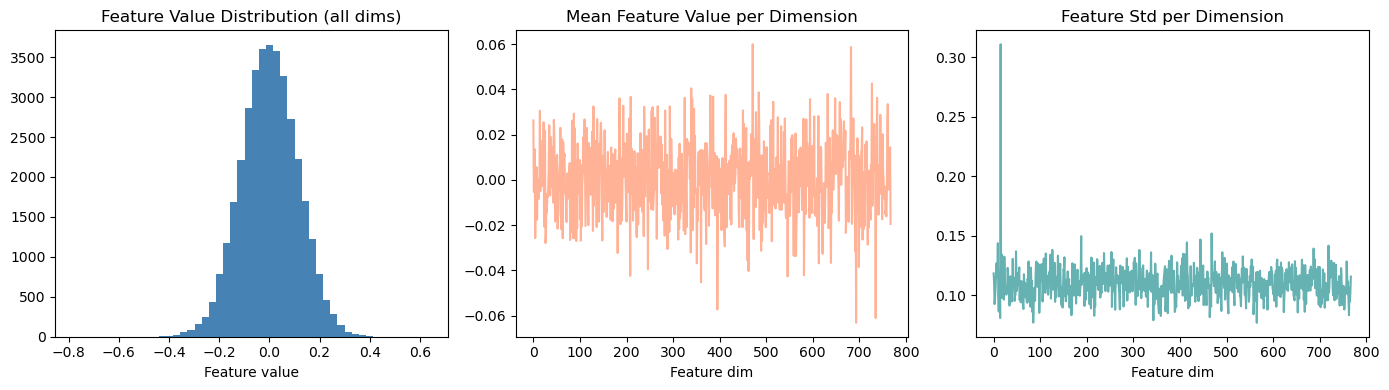

Active dims (std>0.1): 79%


In [7]:
# Feature distribution visualization
convnext_eval = ConvNeXtBackbone(pretrained=False).to(device)

n_samples = 50
all_feats = []
with torch.no_grad():
    for _ in range(n_samples // B):
        x = torch.randn(B, 3, 224, 224).to(device)
        f = convnext_eval(x)
        all_feats.append(f.cpu().numpy())

feats_np = np.concatenate(all_feats, axis=0)  # (n_samples, 768)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(feats_np.flatten(), bins=50, color="steelblue", edgecolor="none")
axes[0].set_title("Feature Value Distribution (all dims)")
axes[0].set_xlabel("Feature value")

feat_means = feats_np.mean(axis=0)
axes[1].plot(feat_means, alpha=0.6, color="coral")
axes[1].set_title("Mean Feature Value per Dimension")
axes[1].set_xlabel("Feature dim")

feat_stds = feats_np.std(axis=0)
axes[2].plot(feat_stds, alpha=0.6, color="teal")
axes[2].set_title("Feature Std per Dimension")
axes[2].set_xlabel("Feature dim")

plt.tight_layout()
plt.savefig("../reports/backbone_features.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Active dims (std>0.1): {(feat_stds > 0.1).mean()*100:.0f}%")

## 7. Transfer Learning Plan

How to fine-tune the backbone on ophthalmology images.

In [8]:
print("""
FINE-TUNING STRATEGY:
─────────────────────────────────────────────────────────────────
Phase 1 (Epochs 1-10):   Freeze backbone, train head only
  LR = 3e-4 for head, backbone = frozen
  Purpose: initialize head without corrupting ImageNet features

Phase 2 (Epochs 11-50):  Unfreeze all, fine-tune end-to-end
  LR = 3e-5 for backbone, 3e-4 for head
  Discriminative learning rates (lower for early layers)

Augmentations for fundus images:
  ✓ RandomRotation(±15°)        — fundus can be slightly rotated
  ✓ ColorJitter(brightness=0.2)  — exposure variation
  ✓ GaussianBlur                 — simulate blur from media opacity
  ✗ RandomHorizontalFlip         — NEVER flip (laterality matters!)
  ✗ Random crop                  — optic disc must remain visible
─────────────────────────────────────────────────────────────────

→ Next: 07_temporal_modeling.ipynb
""")


FINE-TUNING STRATEGY:
─────────────────────────────────────────────────────────────────
Phase 1 (Epochs 1-10):   Freeze backbone, train head only
  LR = 3e-4 for head, backbone = frozen
  Purpose: initialize head without corrupting ImageNet features

Phase 2 (Epochs 11-50):  Unfreeze all, fine-tune end-to-end
  LR = 3e-5 for backbone, 3e-4 for head
  Discriminative learning rates (lower for early layers)

Augmentations for fundus images:
  ✓ RandomRotation(±15°)        — fundus can be slightly rotated
  ✓ ColorJitter(brightness=0.2)  — exposure variation
  ✓ GaussianBlur                 — simulate blur from media opacity
  ✗ RandomHorizontalFlip         — NEVER flip (laterality matters!)
  ✗ Random crop                  — optic disc must remain visible
─────────────────────────────────────────────────────────────────

→ Next: 07_temporal_modeling.ipynb

